In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
path = "E:/Documents/dtms69/filtered_data_dec.csv"

In [3]:
df = pd.read_csv(path, index_col=None)

In [4]:
df

,PEA_No,DATE_Time,KWH,SelfRead_KWH,VA,VB,VC,AA,AB,AC,KVARH_DEL,KVARH_REC,KWHExport,SelfRead_KWHEXP
0,6200022544,2025-12-01 00:00:00,0.007,12165.236,233.0,NaN,NaN,0.0,NaN,NaN,0.000,0.001,0.0,0.000
1,6200022544,2025-12-01 00:15:00,0.007,0.000,233.0,NaN,NaN,0.0,NaN,NaN,0.000,0.000,0.0,0.000
2,6200030933,2025-12-01 00:00:00,0.180,22210.018,234.0,NaN,NaN,2.0,NaN,NaN,0.045,0.000,0.0,0.000
3,6200030933,2025-12-01 00:15:00,0.110,0.000,234.0,NaN,NaN,2.0,NaN,NaN,0.045,0.000,0.0,0.000
4,6200031047,2025-12-01 00:00:00,0.074,33005.131,233.0,NaN,NaN,1.0,NaN,NaN,0.013,0.000,0.0,3569.829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56420,6200032198,2025-12-31 23:45:00,0.017,0.000,233.0,NaN,NaN,0.0,NaN,NaN,0.000,0.011,0.0,0.000
56421,6200050504,2025-12-31 23:45:00,0.061,0.000,233.0,NaN,NaN,1.0,NaN,NaN,0.016,0.000,0.0,0.000
56422,6200061392,2025-12-31 23:45:00,0.800,0.000,232.0,231.0,234.0,14.0,0.0,1.0,0.214,0.000,0.0,0.000
56423,6200118626,2025-12-31 23:30:00,0.014,0.000,235.0,NaN,NaN,0.0,NaN,NaN,0.000,0.002,0.0,0.000


In [100]:
df2 = df.copy()

In [101]:
df2.insert(df2.columns.get_loc('KWH') + 1, 'kW average', df2['KWH'] * 4)

In [102]:
df2.insert(df2.columns.get_loc('KWHExport') + 1, 'kW exp average', df2['KWHExport'] * 4)

In [103]:
df2 = df2.drop(columns=['VA', 'VB', 'VC', 'SelfRead_KWH', 'SelfRead_KWHEXP','KWHExport', 'KVARH_REC', 'KVARH_DEL'])

In [104]:
finergy_list = [6200032193, 6200031047, 6200031051,
            6200031052, 6200031088, 6200032194, 6200031074]

df2['Finergy'] = np.where(df['PEA_No'].isin(finergy_list), 'true', 'false')

In [105]:
mapping = {
    'AA': 'A',
    'AB': 'B',
    'AC': 'C'
}

df2['Phase'] = (
    df2[['AA', 'AB', 'AC']]
    .notna()
    .idxmax(axis=1)
    .map(mapping)
)

In [106]:
df2[['AA', 'AB', 'AC']] = df2[['AA', 'AB', 'AC']].fillna(0)

In [107]:
df2['PEA_No'] = df2['PEA_No'].astype('string')

In [108]:
# print(df2['DATE_Time'].dtype)

df2['DATE_Time'] = pd.to_datetime(df2['DATE_Time'])

In [109]:
df2 = df2.sort_values(
    by=['PEA_No', 'DATE_Time']
).reset_index(drop=True)


In [110]:
df2

,PEA_No,DATE_Time,KWH,kW average,AA,AB,AC,kW exp average,Finergy,Phase
0,6200022544,2025-12-01 00:00:00,0.007,0.028,0.0,0.0,0.0,0.0,false,A
1,6200022544,2025-12-01 00:15:00,0.007,0.028,0.0,0.0,0.0,0.0,false,A
2,6200022544,2025-12-01 00:30:00,0.007,0.028,0.0,0.0,0.0,0.0,false,A
3,6200022544,2025-12-01 00:45:00,0.006,0.024,0.0,0.0,0.0,0.0,false,A
4,6200022544,2025-12-01 01:00:00,0.007,0.028,0.0,0.0,0.0,0.0,false,A
...,...,...,...,...,...,...,...,...,...,...
56420,6200118626,2025-12-31 22:45:00,0.008,0.032,0.0,0.0,0.0,0.0,false,A
56421,6200118626,2025-12-31 23:00:00,0.000,0.000,0.0,0.0,0.0,0.0,false,A
56422,6200118626,2025-12-31 23:15:00,0.006,0.024,0.0,0.0,0.0,0.0,false,A
56423,6200118626,2025-12-31 23:30:00,0.014,0.056,0.0,0.0,0.0,0.0,false,A


In [111]:
# print(df2['ServicePointID'].nunique())
print(df2['PEA_No'].nunique())

19


In [112]:
df2.value_counts(['PEA_No'])

PEA_No    
6200022544    2976
6200030933    2976
6200031047    2976
6200031052    2976
6200031073    2976
6200031074    2976
6200031086    2976
6200031088    2976
6200031087    2976
6200032193    2976
6200031902    2976
6200032198    2976
6200050504    2976
6200032194    2976
6200032196    2976
6200061392    2976
6200118626    2976
6200031085    2952
6200031051    2881
Name: count, dtype: int64

In [113]:
s = pd.to_datetime(df2['DATE_Time']).dropna().drop_duplicates().sort_values()

start = s.min().floor('15min')
end   = s.max().ceil('15min') - pd.Timedelta(minutes=15)  

full = pd.date_range(start, end, freq='15min')

In [114]:
day_count = pd.Series(s).groupby(pd.Series(s).dt.date).size()
incomplete_days = day_count[day_count < 96]
print(incomplete_days)

Series([], Name: DATE_Time, dtype: int64)


In [115]:
print(day_count.shape[0])

31


In [116]:
# ถ้า period ตรง 1 เดือนพอดี และคาดหวัง 96 จุด/วัน
expected = 96 * day_count.shape[0]         # คิดจากจำนวนวันจริงที่พบ
actual   = len(s)
print("expected:", expected, "actual:", actual, "missing:", expected - actual)

expected: 2976 actual: 2976 missing: 0


In [117]:
# 1 เดือน = 31 วัน → 2976 จุด
expected_fixed = 96 * 31
print("fixed_expected:", expected_fixed, "missing:", expected_fixed - actual)

fixed_expected: 2976 missing: 0


In [118]:
df2[df2[['PEA_No']].isnull().all(axis=1)]

,PEA_No,DATE_Time,KWH,kW average,AA,AB,AC,kW exp average,Finergy,Phase


In [119]:
df3 = df2.copy()

In [120]:
df3['date'] = df2['DATE_Time'].dt.date

counts_per_day = (
    df3.groupby(['PEA_No', 'date']).size().reset_index(name='count')
)

In [121]:
missing_days = counts_per_day.query("count < 96")
print(missing_days)

         PEA_No        date  count
106  6200031051  2025-12-14      1
230  6200031085  2025-12-14     73
231  6200031085  2025-12-15     95


In [122]:
pivot = counts_per_day.pivot(index='date', columns='PEA_No', values='count').fillna(0)
pivot

PEA_No,6200022544,6200030933,6200031047,6200031051,6200031052,6200031073,6200031074,6200031085,6200031086,6200031087,6200031088,6200031902,6200032193,6200032194,6200032196,6200032198,6200050504,6200061392,6200118626
date,,,,,,,,,,,,,,,,,,,
2025-12-01,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
2025-12-02,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
2025-12-03,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
2025-12-04,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
2025-12-05,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
2025-12-06,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
2025-12-07,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
2025-12-08,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
2025-12-09,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96


In [123]:
df2.isna().sum()

PEA_No            0
DATE_Time         0
KWH               1
kW average        1
AA                0
AB                0
AC                0
kW exp average    1
Finergy           0
Phase             0
dtype: int64

In [124]:
df2.isnull().sum()

PEA_No            0
DATE_Time         0
KWH               1
kW average        1
AA                0
AB                0
AC                0
kW exp average    1
Finergy           0
Phase             0
dtype: int64

In [125]:
print(df2.loc[df2['KWH'].isna(), 'DATE_Time'])
idx = df2[df2['KWH'].isna()].index[0]
print(idx)

10177   2025-12-15
Name: DATE_Time, dtype: datetime64[ns]
10177


In [126]:
df2.loc[idx-5:idx+5]

,PEA_No,DATE_Time,KWH,kW average,AA,AB,AC,kW exp average,Finergy,Phase
10172,6200031051,2025-12-13 23:00:00,0.308000,1.232000,6.0,0.0,0.0,0.0,true,A
10173,6200031051,2025-12-13 23:15:00,0.309000,1.236000,6.0,0.0,0.0,0.0,true,A
10174,6200031051,2025-12-13 23:30:00,0.314000,1.256000,6.0,0.0,0.0,0.0,true,A
10175,6200031051,2025-12-13 23:45:00,0.303000,1.212000,6.0,0.0,0.0,0.0,true,A
10176,6200031051,2025-12-14 00:00:00,0.301000,1.204000,6.0,0.0,0.0,0.0,true,A
10177,6200031051,2025-12-15 00:00:00,NaN,NaN,0.0,0.0,0.0,NaN,true,A
10178,6200031051,2025-12-15 00:15:00,0.089001,0.356003,0.0,0.0,0.0,0.0,true,A
10179,6200031051,2025-12-15 00:30:00,0.066609,0.266435,0.0,0.0,0.0,0.0,true,A
10180,6200031051,2025-12-15 00:45:00,0.078230,0.312920,0.0,0.0,0.0,0.0,true,A
10181,6200031051,2025-12-15 01:00:00,0.051586,0.206346,0.0,0.0,0.0,0.0,true,A


In [127]:
df_1085 = df2[
    (df2['PEA_No'] == '6200031085') &
    (df2['DATE_Time'] >= '2025-12-14 16:00:00') &
    (df2['DATE_Time'] <= '2025-12-15 06:00:00')
]
print(df_1085.to_string())

           PEA_No           DATE_Time    KWH  kW average   AA   AB   AC  kW exp average Finergy Phase
22049  6200031085 2025-12-14 16:00:00  0.222       0.888  4.0  0.0  0.0             0.0   false     A
22050  6200031085 2025-12-14 16:15:00  0.219       0.876  4.0  0.0  0.0             0.0   false     A
22051  6200031085 2025-12-14 16:30:00  0.096       0.384  2.0  0.0  0.0             0.0   false     A
22052  6200031085 2025-12-14 16:45:00  0.006       0.024  0.0  0.0  0.0             0.0   false     A
22053  6200031085 2025-12-14 17:00:00  0.057       0.228  1.0  0.0  0.0             0.0   false     A
22054  6200031085 2025-12-14 17:15:00  0.207       0.828  4.0  0.0  0.0             0.0   false     A
22055  6200031085 2025-12-14 17:30:00  0.211       0.844  4.0  0.0  0.0             0.0   false     A
22056  6200031085 2025-12-14 17:45:00  0.211       0.844  4.0  0.0  0.0             0.0   false     A
22057  6200031085 2025-12-14 18:00:00  0.179       0.716  3.0  0.0  0.0           

In [ ]:
#ซ่อมค่า Missing Values

In [128]:
df2= df2.drop(index=10177)

In [129]:
source_day = df2[
    (df2['PEA_No'] == '6200031051') &
    (df2['DATE_Time'] >= '2025-12-21 00:00:00') &
    (df2['DATE_Time'] <= '2025-12-22 00:00:00')
].copy()

len(source_day)

97

In [130]:
source_day['DATE_Time'] = (
    source_day['DATE_Time']
    - pd.Timedelta(days=7)
)
source_day

,PEA_No,DATE_Time,KWH,kW average,AA,AB,AC,kW exp average,Finergy,Phase
10753,6200031051,2025-12-14 00:00:00,0.124000,0.496000,2.0,0.0,0.0,0.0,true,A
10754,6200031051,2025-12-14 00:15:00,0.107333,0.429333,0.0,0.0,0.0,0.0,true,A
10755,6200031051,2025-12-14 00:30:00,0.114667,0.458667,0.0,0.0,0.0,0.0,true,A
10756,6200031051,2025-12-14 00:45:00,0.092667,0.370667,0.0,0.0,0.0,0.0,true,A
10757,6200031051,2025-12-14 01:00:00,0.089333,0.357333,0.0,0.0,0.0,0.0,true,A
...,...,...,...,...,...,...,...,...,...,...
10845,6200031051,2025-12-14 23:00:00,0.178000,0.712000,3.0,0.0,0.0,0.0,true,A
10846,6200031051,2025-12-14 23:15:00,0.131000,0.524000,3.0,0.0,0.0,0.0,true,A
10847,6200031051,2025-12-14 23:30:00,0.132000,0.528000,3.0,0.0,0.0,0.0,true,A
10848,6200031051,2025-12-14 23:45:00,0.131000,0.524000,3.0,0.0,0.0,0.0,true,A


In [131]:
df2 = pd.concat(
    [df2, source_day],
    ignore_index=True
)

In [132]:
df2 = (
    df2
    .sort_values(['PEA_No', 'DATE_Time'])
    .reset_index(drop=True)
)

In [ ]:
#ซ่อม 6200031085

In [133]:
source_day = df2[
    (df2['PEA_No'] == '6200031085') &
    (df2['DATE_Time'] >= '2025-12-21 18:15:00') &
    (df2['DATE_Time'] <= '2025-12-22 00:00:00')
].copy()

len(source_day)

24

In [134]:
source_day['DATE_Time'] = (
    source_day['DATE_Time']
    - pd.Timedelta(days=7)
)
source_day

,PEA_No,DATE_Time,KWH,kW average,AA,AB,AC,kW exp average,Finergy,Phase
22802,6200031085,2025-12-14 18:15:00,0.215,0.860,4.0,0.0,0.0,0.0,false,A
22803,6200031085,2025-12-14 18:30:00,0.154,0.616,3.0,0.0,0.0,0.0,false,A
22804,6200031085,2025-12-14 18:45:00,0.225,0.900,4.0,0.0,0.0,0.0,false,A
22805,6200031085,2025-12-14 19:00:00,0.138,0.552,2.0,0.0,0.0,0.0,false,A
22806,6200031085,2025-12-14 19:15:00,0.168,0.672,3.0,0.0,0.0,0.0,false,A
22807,6200031085,2025-12-14 19:30:00,0.041,0.164,1.0,0.0,0.0,0.0,false,A
22808,6200031085,2025-12-14 19:45:00,0.041,0.164,1.0,0.0,0.0,0.0,false,A
22809,6200031085,2025-12-14 20:00:00,0.041,0.164,1.0,0.0,0.0,0.0,false,A
22810,6200031085,2025-12-14 20:15:00,0.041,0.164,1.0,0.0,0.0,0.0,false,A
22811,6200031085,2025-12-14 20:30:00,0.042,0.168,1.0,0.0,0.0,0.0,false,A


In [135]:
df2 = pd.concat(
    [df2, source_day],
    ignore_index=True
)

In [136]:
df2 = (
    df2
    .sort_values(['PEA_No', 'DATE_Time'])
    .reset_index(drop=True)
)

In [ ]:
#เช็คซ้ำอีกครั้ง

In [137]:
df3 = df2.copy()

In [138]:
df3['date'] = df2['DATE_Time'].dt.date

In [139]:
counts_per_day = (
    df3.groupby(['PEA_No', 'date']).size().reset_index(name='count')
)

In [140]:
missing_days = counts_per_day.query("count < 96")
print(missing_days)

Empty DataFrame
Columns: [PEA_No, date, count]
Index: []


In [141]:
df2.isna().sum()

PEA_No            0
DATE_Time         0
KWH               0
kW average        0
AA                0
AB                0
AC                0
kW exp average    0
Finergy           0
Phase             0
dtype: int64

In [142]:
df2.isnull().sum()

PEA_No            0
DATE_Time         0
KWH               0
kW average        0
AA                0
AB                0
AC                0
kW exp average    0
Finergy           0
Phase             0
dtype: int64

In [143]:
print(df2['AA'].isnull().sum())
print(df2['AB'].isnull().sum())
print(df2['AC'].isnull().sum())

0
0
0


In [144]:
df2 = df2.set_index('DATE_Time')
# df2 = df2.reset_index()

In [145]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 56545 entries, 2025-12-01 00:00:00 to 2025-12-31 23:45:00
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PEA_No          56545 non-null  string 
 1   KWH             56545 non-null  float64
 2   kW average      56545 non-null  float64
 3   AA              56545 non-null  float64
 4   AB              56545 non-null  float64
 5   AC              56545 non-null  float64
 6   kW exp average  56545 non-null  float64
 7   Finergy         56545 non-null  object 
 8   Phase           56545 non-null  object 
dtypes: float64(6), object(2), string(1)
memory usage: 4.3+ MB


In [146]:
df2.describe()

,KWH,kW average,AA,AB,AC,kW exp average
count,56545.000000,56545.000000,56545.000000,56545.0,56545.000000,56545.000000
mean,0.137417,0.549670,1.926289,0.0,0.080095,0.108803
std,0.245687,0.982749,4.682511,0.0,0.366527,0.380815
min,0.000000,0.000000,-12.000000,0.0,0.000000,0.000000
25%,0.018000,0.072000,0.000000,0.0,0.000000,0.000000
50%,0.056000,0.224000,1.000000,0.0,0.000000,0.000000
75%,0.132000,0.528000,2.000000,0.0,0.000000,0.000000
max,2.148000,8.592000,38.000000,0.0,5.000000,2.812000


In [147]:
df_plot = (
    df2.groupby('DATE_Time')['kW average']
       .sum()
       .reset_index()
)

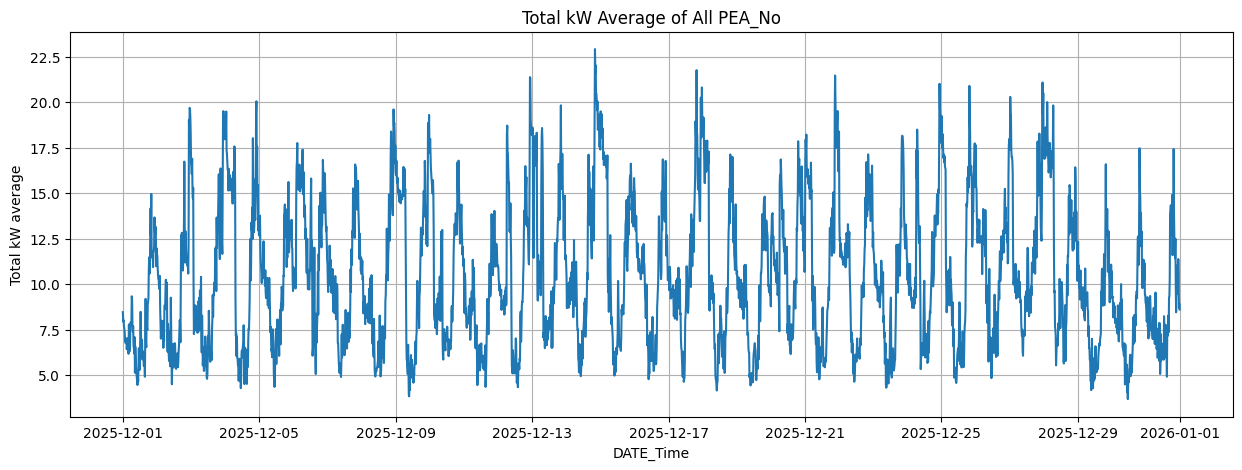

In [148]:
plt.figure(figsize=(15,5))
plt.plot(df_plot['DATE_Time'], df_plot['kW average'])
plt.xlabel('DATE_Time')
plt.ylabel('Total kW average')
plt.title('Total kW Average of All PEA_No')
plt.grid(True)
plt.show()

In [149]:
output_path = "E:/Documents/dtms69/LP_dec2026.parquet"

In [150]:
df2.to_parquet(output_path, engine='pyarrow', index=False)